In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
data = pd.read_csv("../data/raw/CEAS_08.csv")

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [3]:
print("Number of rows:", data.shape[0])
print("Number of columns:", data.shape[1])

Number of rows: 39154
Number of columns: 7


In [5]:
data.head()

,sender,receiver,date,subject,body,label,urls
0,Young Esposito <Young@iworld.de>,user4@gvc.ceas-challenge.cc,"Tue, 05 Aug 2008 16:31:02 -0700",Never agree to be a loser,"Buck up, your troubles caused by small dimensi...",1,1
1,Mok <ipline's1983@icable.ph>,user2.2@gvc.ceas-challenge.cc,"Tue, 05 Aug 2008 18:31:03 -0500",Befriend Jenna Jameson,\nUpgrade your sex and pleasures with these te...,1,1
2,Daily Top 10 <Karmandeep-opengevl@universalnet...,user2.9@gvc.ceas-challenge.cc,"Tue, 05 Aug 2008 20:28:00 -1200",CNN.com Daily Top 10,>+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+...,1,1
3,Michael Parker <ivqrnai@pobox.com>,SpamAssassin Dev <xrh@spamassassin.apache.org>,"Tue, 05 Aug 2008 17:31:20 -0600",Re: svn commit: r619753 - in /spamassassin/tru...,Would anyone object to removing .so from this ...,0,1
4,Gretchen Suggs <externalsep1@loanofficertool.com>,user2.2@gvc.ceas-challenge.cc,"Tue, 05 Aug 2008 19:31:21 -0400",SpecialPricesPharmMoreinfo,\nWelcomeFastShippingCustomerSupport\nhttp://7...,1,1


In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39154 entries, 0 to 39153
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   sender    39154 non-null  object
 1   receiver  38692 non-null  object
 2   date      39154 non-null  object
 3   subject   39126 non-null  object
 4   body      39154 non-null  object
 5   label     39154 non-null  int64 
 6   urls      39154 non-null  int64 
dtypes: int64(2), object(5)
memory usage: 2.1+ MB


In [7]:
missing_values = data.isnull().sum()

print("Missing values:")
print(missing_values)

Missing values:
sender        0
receiver    462
date          0
subject      28
body          0
label         0
urls          0
dtype: int64


In [8]:
duplicate_count = data.duplicated().sum()

print("Number of duplicate records:", duplicate_count)

Number of duplicate records: 0


In [9]:
print(data["label"].value_counts())

label
1    21842
0    17312
Name: count, dtype: int64


In [10]:
print(data["label"].value_counts(normalize=True) * 100)

label
1    55.78485
0    44.21515
Name: proportion, dtype: float64


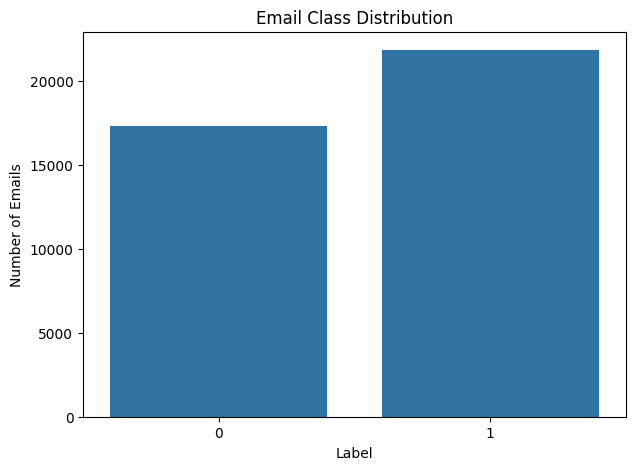

In [11]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=data,
    x="label"
)

plt.title("Email Class Distribution")
plt.xlabel("Label")
plt.ylabel("Number of Emails")

plt.show()

In [12]:
# Subject length
data["subject"] = data["subject"].fillna("").astype(str)

data["subject_length"] = data["subject"].apply(len)

print(data["subject_length"].describe())

count    39154.000000
mean        38.896537
std         20.769595
min          0.000000
25%         25.000000
50%         35.000000
75%         50.000000
max        285.000000
Name: subject_length, dtype: float64


In [13]:
# Email body length
data["body"] = data["body"].fillna("").astype(str)

data["body_length"] = data["body"].apply(len)

print(data["body_length"].describe())

count     39154.000000
mean       1571.079813
std        3615.810576
min          14.000000
25%         224.000000
50%         570.000000
75%        1643.000000
max      143996.000000
Name: body_length, dtype: float64


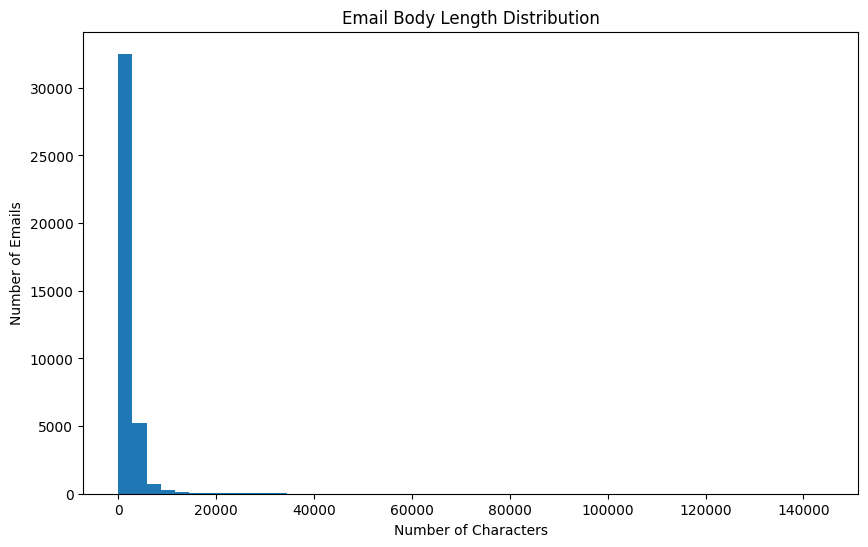

In [14]:
# Body length distribution
plt.figure(figsize=(10, 6))

plt.hist(
    data["body_length"],
    bins=50
)

plt.title("Email Body Length Distribution")
plt.xlabel("Number of Characters")
plt.ylabel("Number of Emails")

plt.show()

In [15]:
# Word count
data["word_count"] = data["body"].apply(
    lambda x: len(x.split())
)

print(data["word_count"].describe())

count    39154.000000
mean       202.034964
std        479.926431
min          1.000000
25%         35.000000
50%         89.000000
75%        247.000000
max      19863.000000
Name: word_count, dtype: float64


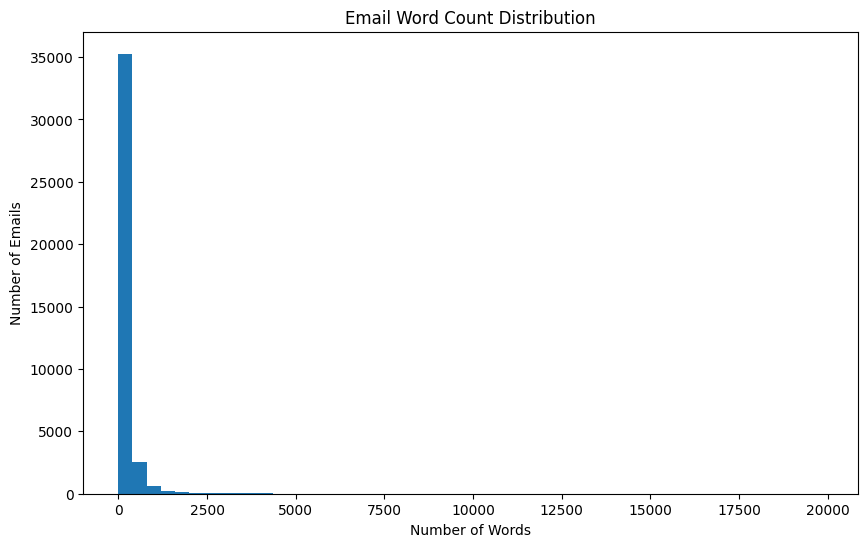

In [16]:
# Word count distribution
plt.figure(figsize=(10, 6))

plt.hist(
    data["word_count"],
    bins=50
)

plt.title("Email Word Count Distribution")
plt.xlabel("Number of Words")
plt.ylabel("Number of Emails")

plt.show()

In [17]:
# URL information
print(data["urls"].value_counts().head(10))

urls
1    26232
0    12922
Name: count, dtype: int64


In [18]:
url_count = data["urls"].notna().sum()

print("Emails with URL information:", url_count)
print("Emails without URL information:", len(data) - url_count)

Emails with URL information: 39154
Emails without URL information: 0


In [19]:
# Date information
print(data["date"].head())
print()
print(data["date"].dtype)

0    Tue, 05 Aug 2008 16:31:02 -0700
1    Tue, 05 Aug 2008 18:31:03 -0500
2    Tue, 05 Aug 2008 20:28:00 -1200
3    Tue, 05 Aug 2008 17:31:20 -0600
4    Tue, 05 Aug 2008 19:31:21 -0400
Name: date, dtype: object

object


In [20]:
data["date"] = pd.to_datetime(
    data["date"],
    errors="coerce"
)

print("Invalid/missing dates:", data["date"].isna().sum())

Invalid/missing dates: 15


C:\Users\rahul\AppData\Local\Temp\ipykernel_13760\3901858776.py:1: FutureWarning: In a future version of pandas, parsing datetimes with mixed time zones will raise an error unless `utc=True`. Please specify `utc=True` to opt in to the new behaviour and silence this warning. To create a `Series` with mixed offsets and `object` dtype, please use `apply` and `datetime.datetime.strptime`
  data["date"] = pd.to_datetime(


In [ ]:
# Sender/receiver exploration
print(data.columns.tolist())

['sender', 'receiver', 'date', 'subject', 'body', 'label', 'urls', 'subject_length', 'body_length', 'word_count']


<Figure size 1000x600 with 0 Axes>

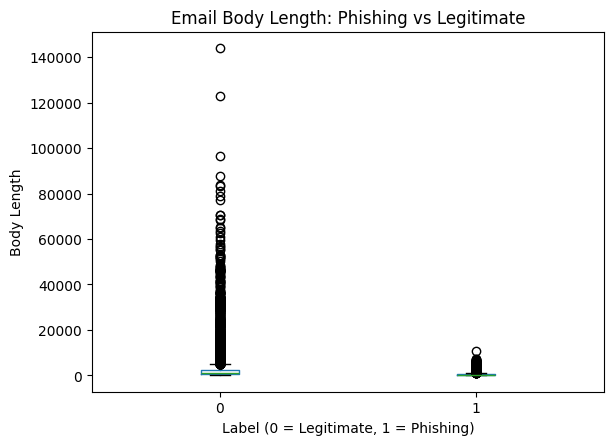

In [22]:
# Phishing vs Legitimate — Email Length
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

data.boxplot(
    column="body_length",
    by="label",
    grid=False
)

plt.title("Email Body Length: Phishing vs Legitimate")
plt.suptitle("")
plt.xlabel("Label (0 = Legitimate, 1 = Phishing)")
plt.ylabel("Body Length")
plt.show()

In [23]:
data.groupby("label")["body_length"].mean()

label
0    2542.186287
1     801.379452
Name: body_length, dtype: float64

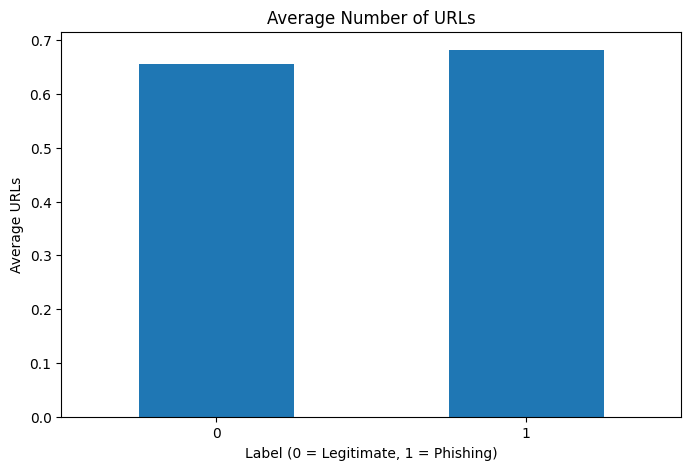

In [24]:
# URL Distribution
plt.figure(figsize=(8, 5))

data.groupby("label")["urls"].mean().plot(kind="bar")

plt.title("Average Number of URLs")
plt.xlabel("Label (0 = Legitimate, 1 = Phishing)")
plt.ylabel("Average URLs")
plt.xticks(rotation=0)
plt.show()

In [25]:
data.groupby("label")["urls"].describe()

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
0,17312.0,0.655210,0.475313,0.0,0.0,1.0,1.0,1.0
1,21842.0,0.681668,0.465840,0.0,0.0,1.0,1.0,1.0


In [26]:
# Sender Domain Analysis
data["sender_domain"] = data["sender"].astype(str).str.extract(
    r'@([\w\.-]+)'
)[0]

In [27]:
data["sender_domain"].value_counts().head(20)

sender_domain
gmail.com                2638
python.org                537
issues.apache.org         462
v.loewis.de               289
massey.ac.nz              284
google.com                239
telefonica.net            209
lists.techtarget.com      199
gvc.ceas-challenge.cc     193
yahoo.com                 185
hotpop.com                183
perl.org                  177
pobox.com                 165
cheimes.de                155
hotmail.com               146
apache.org                124
computer.org              118
porcupine.org             112
canterbury.ac.nz          112
netoyen.net               106
Name: count, dtype: int64

In [ ]:
# This gives us domains where a high percentage of emails are labelled phishing.
domain_stats = pd.crosstab(
    data["sender_domain"],
    data["label"],
    normalize="index"
)

domain_stats["phishing_rate"] = domain_stats[1]

domain_stats.sort_values(
    "phishing_rate",
    ascending=False
).head(20)

label,0,1,phishing_rate
sender_domain,,,
zzyb.com,0.0,1.0,1.0
00freehost.com,0.0,1.0,1.0
zymed.com,0.0,1.0,1.0
0120874874.com,0.0,1.0,1.0
014.am,0.0,1.0,1.0
0166.co.jp,0.0,1.0,1.0
01mm.com,0.0,1.0,1.0
zonta.org,0.0,1.0,1.0
zonderland.nl,0.0,1.0,1.0


In [29]:
data.isnull().sum()

sender              0
receiver          462
date               15
subject             0
body                0
label               0
urls                0
subject_length      0
body_length         0
word_count          0
sender_domain     955
dtype: int64

In [30]:
data.duplicated(subset=["subject", "body"]).sum()

np.int64(0)

In [31]:
# summary of the dataset
print("Dataset Shape:", data.shape)

print("\nLabel Distribution:")
print(data["label"].value_counts())

print("\nMissing Values:")
print(data.isnull().sum())

print("\nDuplicate Emails:")
print(data.duplicated(subset=["subject", "body"]).sum())

print("\nAverage Body Length by Label:")
print(data.groupby("label")["body_length"].mean())

print("\nAverage URLs by Label:")
print(data.groupby("label")["urls"].mean())

Dataset Shape: (39154, 11)

Label Distribution:
label
1    21842
0    17312
Name: count, dtype: int64

Missing Values:
sender              0
receiver          462
date               15
subject             0
body                0
label               0
urls                0
subject_length      0
body_length         0
word_count          0
sender_domain     955
dtype: int64

Duplicate Emails:
0

Average Body Length by Label:
label
0    2542.186287
1     801.379452
Name: body_length, dtype: float64

Average URLs by Label:
label
0    0.655210
1    0.681668
Name: urls, dtype: float64
